In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print("Ready")

Ready


In [2]:
df = yf.download("AAPL", start="2022-01-01",
                 end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
price = df["Close"]

print(f"Loaded {len(price)} observations")
print(f"Date range: {price.index[0].date()} to {price.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed

Loaded 501 observations
Date range: 2022-01-03 to 2023-12-29


In [5]:
def compute_rsi(price, period=14):
    """
    Compute RSI indicator.
    Above 70 = overbought (potential sell)
    Below 30 = oversold (potential buy)
    """
    price    = price.squeeze()  # ensure it's a 1D series
    delta    = price.diff()
    gains    = delta.clip(lower=0)
    losses   = -delta.clip(upper=0)
    avg_gain = gains.ewm(com=period-1, adjust=False).mean()
    avg_loss = losses.ewm(com=period-1, adjust=False).mean()
    rs       = avg_gain / avg_loss
    rsi      = 100 - (100 / (1 + rs))
    return rsi

rsi = compute_rsi(price)

print(f"RSI current value     : {rsi.iloc[-1]:.2f}")
print(f"RSI max value         : {rsi.max():.2f}")
print(f"RSI min value         : {rsi.min():.2f}")
print(f"Days overbought (>70) : {(rsi > 70).sum()}")
print(f"Days oversold   (<30) : {(rsi < 30).sum()}")

RSI current value     : 51.12
RSI max value         : 77.69
RSI min value         : 0.00
Days overbought (>70) : 35
Days oversold   (<30) : 23


In [6]:
def compute_macd(price, fast=12, slow=26, signal=9):
    """
    Compute MACD indicator.
    Buy signal: MACD crosses above signal line
    Sell signal: MACD crosses below signal line
    """
    price       = price.squeeze()
    ema_fast    = price.ewm(span=fast,   adjust=False).mean()
    ema_slow    = price.ewm(span=slow,   adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram   = macd_line - signal_line
    return macd_line, signal_line, histogram

macd, signal_line, histogram = compute_macd(price)

print(f"MACD current value   : {macd.iloc[-1]:.4f}")
print(f"Signal current value : {signal_line.iloc[-1]:.4f}")
print(f"Histogram current    : {histogram.iloc[-1]:.4f}")
print(f"\nCurrent signal: {'BULLISH - MACD above signal' if macd.iloc[-1] > signal_line.iloc[-1] else 'BEARISH - MACD below signal'}")

MACD current value   : 1.5566
Signal current value : 2.4201
Histogram current    : -0.8635

Current signal: BEARISH - MACD below signal


In [7]:
def compute_bbands(price, window=20, num_std=2):
    """
    Compute Bollinger Bands.
    Price at lower band = oversold signal
    Price at upper band = overbought signal
    %B below 0 = price broke below lower band (very rare)
    %B above 1 = price broke above upper band (very rare)
    """
    price  = price.squeeze()
    sma    = price.rolling(window).mean()
    std    = price.rolling(window).std()
    upper  = sma + num_std * std
    lower  = sma - num_std * std
    pct_b  = (price - lower) / (upper - lower)
    return upper, sma, lower, pct_b

upper, mid, lower, pct_b = compute_bbands(price)

print(f"Current price      : ${price.iloc[-1]:.2f}")
print(f"Upper band         : ${upper.iloc[-1]:.2f}")
print(f"Middle band (SMA)  : ${mid.iloc[-1]:.2f}")
print(f"Lower band         : ${lower.iloc[-1]:.2f}")
print(f"%%B value           : {pct_b.iloc[-1]:.2f}")
print(f"\nDays touching upper band : {(pct_b > 0.95).sum()}")
print(f"Days touching lower band : {(pct_b < 0.05).sum()}")

Current price      : $190.38
Upper band         : $196.60
Middle band (SMA)  : $192.13
Lower band         : $187.67
%%B value           : 0.30

Days touching upper band : 38
Days touching lower band : 32


[*********************100%***********************]  1 of 1 completed


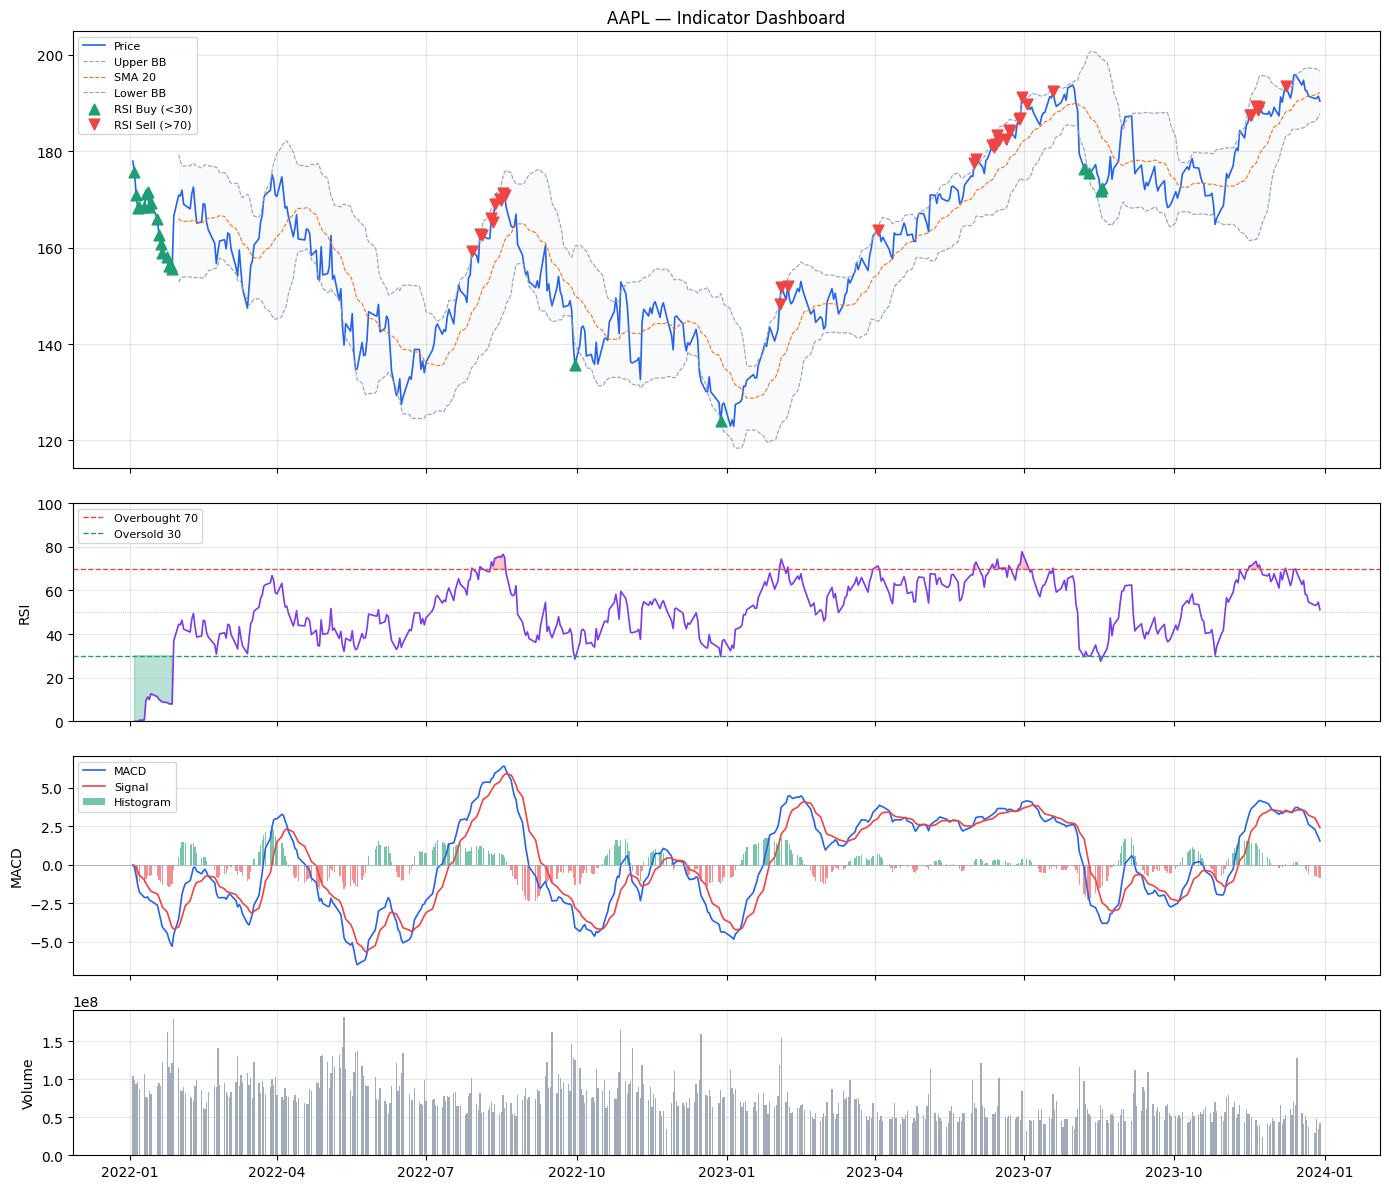

In [8]:
def indicator_dashboard(ticker, start="2022-01-01", end="2024-01-01"):
    """
    4-panel indicator dashboard.
    Panel 1: Price + Bollinger Bands + RSI signals
    Panel 2: RSI with overbought/oversold zones
    Panel 3: MACD with histogram
    Panel 4: Volume
    """
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    df.columns = df.columns.get_level_values(0)
    price = df["Close"].squeeze()

    # Compute all indicators
    rsi                      = compute_rsi(price)
    macd, signal_line, hist  = compute_macd(price)
    upper, mid, lower, pct_b = compute_bbands(price)

    # RSI signal markers
    rsi_buy  = price[rsi < 30]
    rsi_sell = price[rsi > 70]

    fig, axes = plt.subplots(4, 1, figsize=(14, 12),
        gridspec_kw={'height_ratios': [3, 1.5, 1.5, 1]},
        sharex=True)

    # Panel 1: Price + Bollinger Bands
    axes[0].plot(price, color='#2563eb', lw=1.2, label='Price')
    axes[0].plot(upper, color='#94a3b8', lw=0.8, linestyle='--', label='Upper BB')
    axes[0].plot(mid,   color='#f97316', lw=0.8, linestyle='--', label='SMA 20')
    axes[0].plot(lower, color='#94a3b8', lw=0.8, linestyle='--', label='Lower BB')
    axes[0].fill_between(price.index, upper, lower,
                         alpha=0.05, color='#94a3b8')
    axes[0].scatter(rsi_buy.index,  rsi_buy,
                    color='#1D9E75', marker='^', s=60,
                    zorder=5, label='RSI Buy (<30)')
    axes[0].scatter(rsi_sell.index, rsi_sell,
                    color='#ef4444', marker='v', s=60,
                    zorder=5, label='RSI Sell (>70)')
    axes[0].set_title(f'{ticker} — Indicator Dashboard')
    axes[0].legend(loc='upper left', fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Panel 2: RSI
    axes[1].plot(rsi, color='#7c3aed', lw=1.2)
    axes[1].axhline(70, color='#ef4444', lw=1,
                    linestyle='--', label='Overbought 70')
    axes[1].axhline(30, color='#1D9E75', lw=1,
                    linestyle='--', label='Oversold 30')
    axes[1].axhline(50, color='#94a3b8', lw=0.5, linestyle=':')
    axes[1].fill_between(rsi.index, rsi, 70,
                         where=(rsi > 70), alpha=0.3, color='#ef4444')
    axes[1].fill_between(rsi.index, rsi, 30,
                         where=(rsi < 30), alpha=0.3, color='#1D9E75')
    axes[1].set_ylabel('RSI')
    axes[1].set_ylim(0, 100)
    axes[1].legend(loc='upper left', fontsize=8)
    axes[1].grid(True, alpha=0.3)

    # Panel 3: MACD
    axes[2].plot(macd,        color='#2563eb', lw=1.2, label='MACD')
    axes[2].plot(signal_line, color='#ef4444', lw=1.2, label='Signal')
    colors = ['#1D9E75' if v >= 0 else '#ef4444' for v in hist]
    axes[2].bar(hist.index, hist, color=colors,
                alpha=0.6, label='Histogram')
    axes[2].axhline(0, color='#94a3b8', lw=0.5)
    axes[2].set_ylabel('MACD')
    axes[2].legend(loc='upper left', fontsize=8)
    axes[2].grid(True, alpha=0.3)

    # Panel 4: Volume
    axes[3].bar(df.index, df['Volume'], color='#64748b', alpha=0.6)
    axes[3].set_ylabel('Volume')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run on AAPL
indicator_dashboard("AAPL")

[*********************100%***********************]  1 of 1 completed


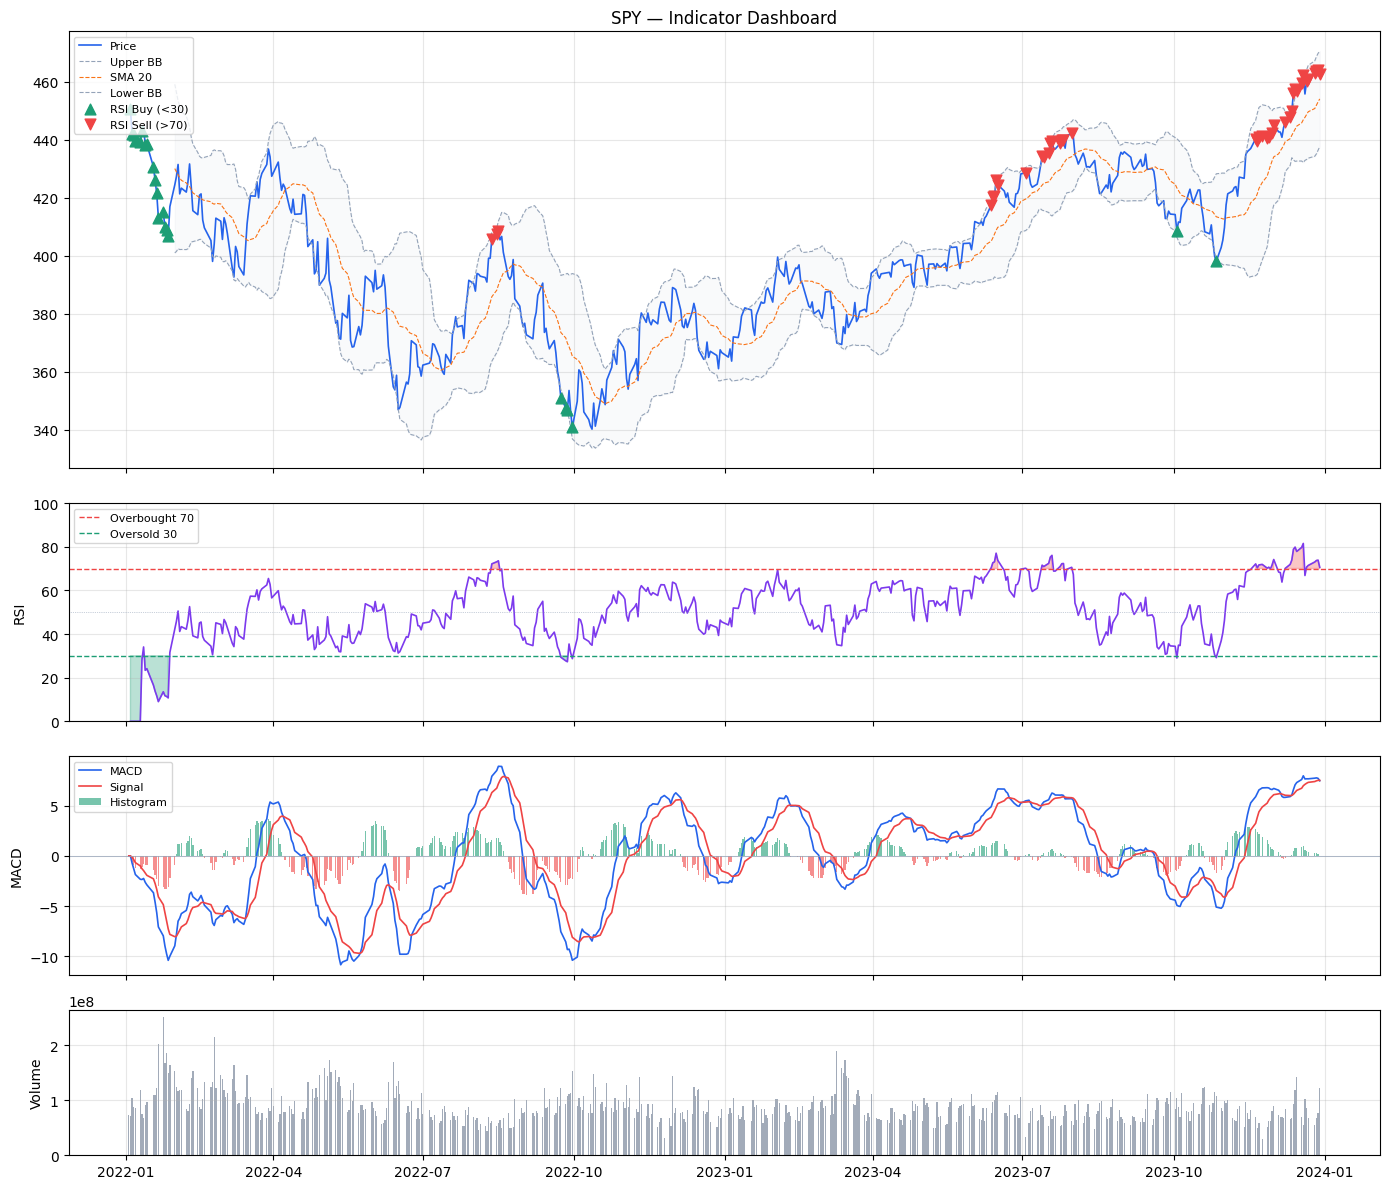

[*********************100%***********************]  1 of 1 completed


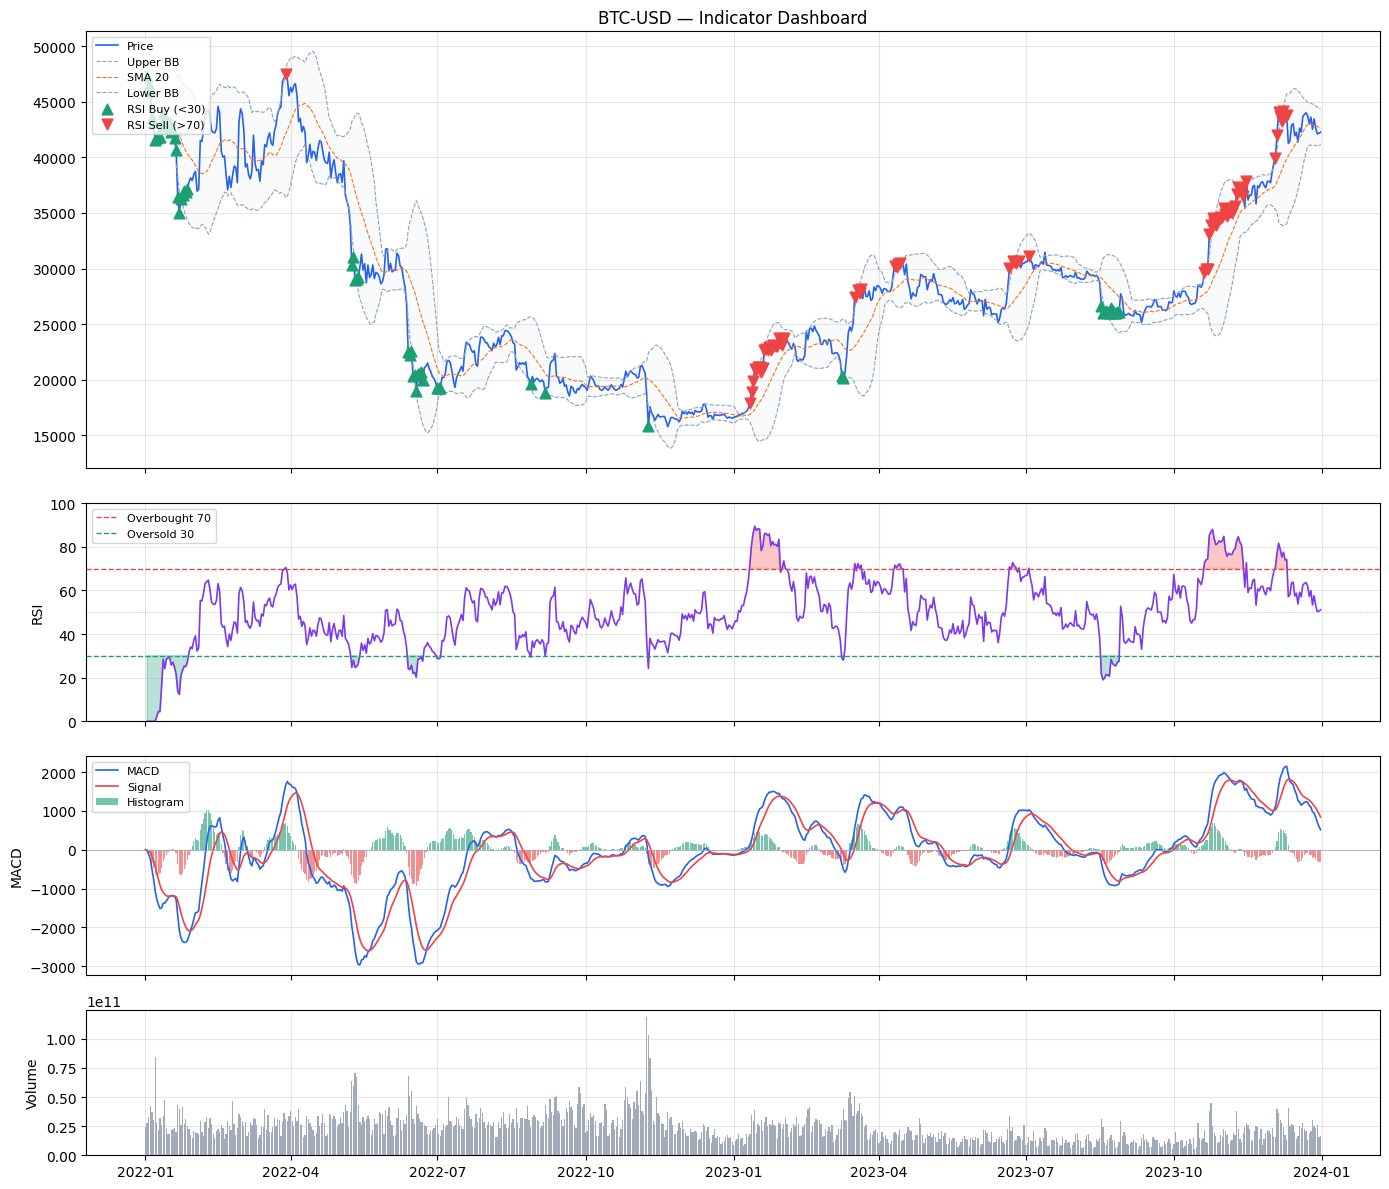

In [9]:
indicator_dashboard("SPY")
indicator_dashboard("BTC-USD")

In [10]:
import inspect

code = """import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

""" + inspect.getsource(compute_rsi) + "\n\n" + inspect.getsource(compute_macd) + "\n\n" + inspect.getsource(compute_bbands) + "\n\n" + inspect.getsource(indicator_dashboard)

with open("../utils/indicators.py", "w", encoding="utf-8") as f:
    f.write(code)

print("Saved to utils/indicators.py")

Saved to utils/indicators.py
